<center>
    <font size="5"> Sieci neuronowe i uczenie głębokie<br/>
        <small><em>Studia stacjonarne II stopnia 2025/2026</em><br/>Kierunek: Matematyka stosowana<br>Specjalność: Analityka danych</small>
    </font>
</center>
<br>



# Laboratorium nr 5: Detekcja obiektów

In [1]:
# !pip install keras-cv opencv-python

In [2]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import xml.etree.ElementTree as ET
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import keras_cv

2026-03-23 22:35:07.666760: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Dataset: Fruit images, Jeden obiekt na obrazie, Model: VGG
Data: https://www.kaggle.com/datasets/mbkinaci/fruit-images-for-object-detection
### Wizualizacja danych

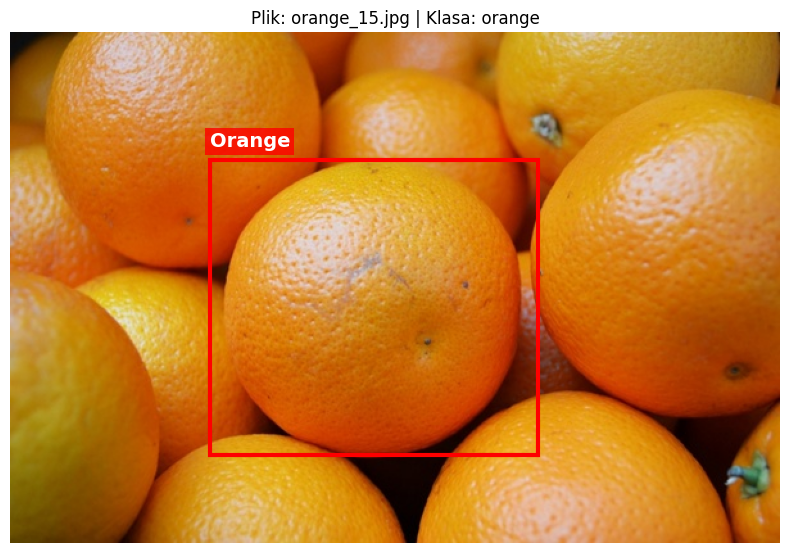

In [ ]:
IMAGE_DIR = "./fruits/train/"
ANNOTATION_DIR = "./fruits/train/"

CLASS_MAPPING = {"apple": 0, "banana": 1, "orange": 2}

sample_xml = "orange_15.xml"
xml_path = os.path.join(ANNOTATION_DIR, sample_xml)

tree = ET.parse(xml_path)
root = tree.getroot()

filename = root.find("filename").text
image_path = os.path.join(IMAGE_DIR, filename)

obj = root.find("object")
class_name = obj.find("name").text

bndbox = obj.find("bndbox")
xmin = int(bndbox.find("xmin").text)
ymin = int(bndbox.find("ymin").text)
xmax = int(bndbox.find("xmax").text)
ymax = int(bndbox.find("ymax").text)

rect_w = xmax - xmin
rect_h = ymax - ymin

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(image_rgb)

rect = patches.Rectangle(
    (xmin, ymin), rect_w, rect_h, linewidth=3, edgecolor="red", facecolor="none"
)
ax.add_patch(rect)
ax.text(
    xmin,
    ymin - 10,
    class_name.capitalize(),
    color="white",
    fontsize=14,
    fontweight="bold",
    bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=3),
)

plt.axis("off")
plt.title(f"Plik: {filename} | Klasa: {class_name}")
plt.tight_layout()
plt.show()

### Przygotowanie danych dla modelu

In [4]:
TARGET_SIZE = (224, 224)

X_images = []
y_classes = []
y_bboxes = []

xml_files = [f for f in os.listdir(ANNOTATION_DIR) if f.endswith(".xml")]

print(f"Znaleziono {len(xml_files)} plików XML.")

for xml_file in xml_files:
    xml_path = os.path.join(ANNOTATION_DIR, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    image_path = os.path.join(IMAGE_DIR, filename)

    if not os.path.exists(image_path):
        continue

    image = cv2.imread(image_path)
    if image is None:
        continue

    # Zamiana kolorów z BGR (OpenCV domyślnie) na RGB (Keras domyślnie)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    # Szukamy pierwszego obiektu (zakładamy, że jest tylko jeden per zdjęcie)
    obj = root.find("object")
    if obj is None:
        continue

    class_name = obj.find("name").text.lower().strip()
    if class_name not in CLASS_MAPPING:
        continue

    bndbox = obj.find("bndbox")
    xmin = float(bndbox.find("xmin").text)
    ymin = float(bndbox.find("ymin").text)
    xmax = float(bndbox.find("xmax").text)
    ymax = float(bndbox.find("ymax").text)

    # Normalizacja współrzędnych do przedziału [0.0, 1.0]
    xmin_norm = xmin / w
    ymin_norm = ymin / h
    xmax_norm = xmax / w
    ymax_norm = ymax / h

    image_resized = cv2.resize(image, TARGET_SIZE)
    image_resized = image_resized.astype("float32") / 255.0
    # image_resized = tf.keras.applications.vgg16.preprocess_input(image_resized)

    X_images.append(image_resized)
    y_classes.append(CLASS_MAPPING[class_name])
    y_bboxes.append([xmin_norm, ymin_norm, xmax_norm, ymax_norm])


X_images = np.array(X_images)
y_bboxes = np.array(y_bboxes, dtype="float32")

# Dla klasyfikacji użyjemy One-Hot Encoding (np. [0, 1, 0] dla banana)
y_classes = to_categorical(y_classes, num_classes=len(CLASS_MAPPING))

print("\nPodsumowanie zbioru danych:")
print(f"Kształt X_images: {X_images.shape}")  # Powinno być (N, 224, 224, 3)
print(f"Kształt y_classes: {y_classes.shape}")  # Powinno być (N, 3)
print(f"Kształt y_bboxes: {y_bboxes.shape}")  # Powinno być (N, 4)

Znaleziono 240 plików XML.

Podsumowanie zbioru danych:
Kształt X_images: (240, 224, 224, 3)
Kształt y_classes: (240, 3)
Kształt y_bboxes: (240, 4)


### Tworzenie modelu

In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

vgg_backbone = VGG16(
    weights="imagenet", include_top=False, input_tensor=Input(shape=(224, 224, 3))
)
vgg_backbone.trainable = False

flatten = Flatten()(vgg_backbone.output)
class_head = Dense(128, activation="relu")(flatten)
class_head = Dropout(0.5)(class_head)
class_output = Dense(3, activation="softmax", name="class_output")(class_head)

box_head = Dense(128, activation="relu")(flatten)
box_head = Dense(64, activation="relu")(box_head)
box_output = Dense(4, activation="sigmoid", name="box_output")(box_head)

model = Model(inputs=vgg_backbone.input, outputs=[class_output, box_output])


model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss={"class_output": "categorical_crossentropy", "box_output": "mse"},
    metrics={"class_output": "accuracy", "box_output": "mse"},
    # Można też dodać loss_weights={'class_output': 1.0, 'box_output': 1.0}, jeśli jeden z członów dominuje
)

model.summary()

I0000 00:00:1774301719.398763  775618 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4078 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 21,146,375 (80.67 MB)

 Trainable params: 6,431,687 (24.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Generowanie wizualizacji...


2026-03-23 22:35:21.251552: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f8eb80042b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-23 22:35:21.251604: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5
2026-03-23 22:35:21.266663: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-23 22:35:21.403558: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-03-23 22:35:23.482841: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[1,512,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,256,28,28]{3,2,1,0}, f32[512,256,3,3]{3,2,1,0}, f32[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_

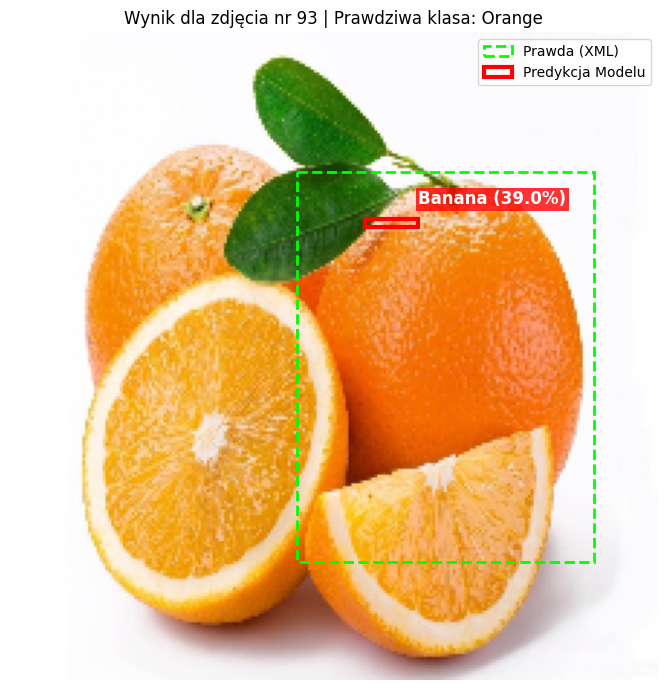

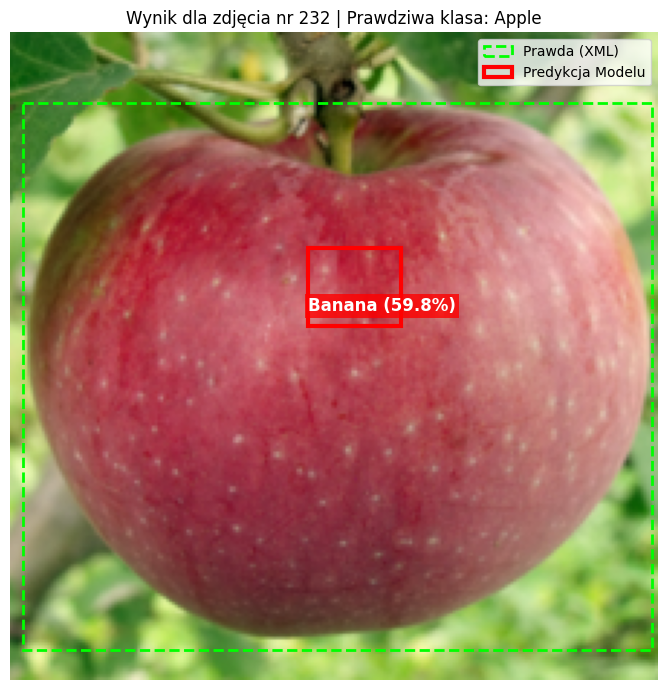

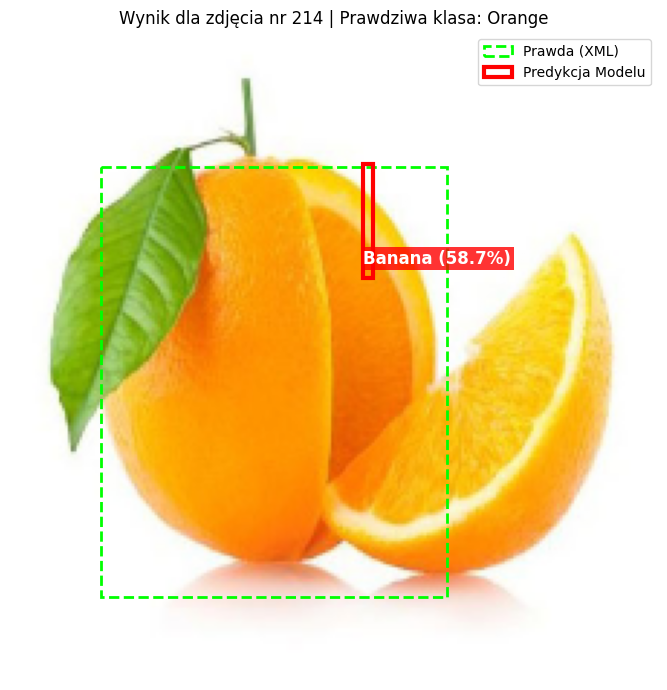

In [6]:
INV_CLASS_MAPPING = {v: k for k, v in CLASS_MAPPING.items()}


def visualize_prediction(index, model):
    image = X_images[index]
    true_box = y_bboxes[index]

    true_class_idx = np.argmax(y_classes[index])
    true_class_name = INV_CLASS_MAPPING[true_class_idx]

    input_image = np.expand_dims(image, axis=0)
    pred_classes, pred_boxes = model.predict(input_image, verbose=0)

    pred_box = pred_boxes[0]
    pred_class_idx = np.argmax(pred_classes[0])
    confidence = pred_classes[0][pred_class_idx]
    pred_class_name = INV_CLASS_MAPPING[pred_class_idx]

    h, w, _ = image.shape
    true_xmin, true_ymin, true_xmax, true_ymax = true_box * [w, h, w, h]
    pred_xmin, pred_ymin, pred_xmax, pred_ymax = pred_box * [w, h, w, h]

    fig, ax = plt.subplots(1, figsize=(7, 7))
    ax.imshow(image)

    true_rect = patches.Rectangle(
        (true_xmin, true_ymin),
        true_xmax - true_xmin,
        true_ymax - true_ymin,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
        linestyle="dashed",
        label="Prawda (XML)",
    )
    ax.add_patch(true_rect)

    pred_rect = patches.Rectangle(
        (pred_xmin, pred_ymin),
        pred_xmax - pred_xmin,
        pred_ymax - pred_ymin,
        linewidth=3,
        edgecolor="red",
        facecolor="none",
        label="Predykcja Modelu",
    )
    ax.add_patch(pred_rect)

    label_text = f"{pred_class_name.capitalize()} ({(confidence * 100):.1f}%)"
    ax.text(
        pred_xmin,
        pred_ymin - 5,
        label_text,
        color="white",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor="red", alpha=0.8, edgecolor="none", pad=2),
    )

    plt.legend(loc="upper right")
    plt.axis("off")
    plt.title(
        f"Wynik dla zdjęcia nr {index} | Prawdziwa klasa: {true_class_name.capitalize()}"
    )
    plt.tight_layout()
    plt.show()


print("Generowanie wizualizacji...")
for _ in range(3):
    random_idx = np.random.randint(0, len(X_images) - 1)
    visualize_prediction(random_idx, model)

In [7]:
history = model.fit(
    X_images,
    {"class_output": y_classes, "box_output": y_bboxes},
    validation_split=0.2,
    batch_size=32,
    epochs=15,
)

# Zapisanie modelu po treningu
model.save("vgg16_fruit_detector.weights.h5")

Epoch 1/15


2026-03-23 22:35:29.716790: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-23 22:35:29.853648: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - box_output_loss: 0.0940 - box_output_mse: 0.0940 - class_output_accuracy: 0.3238 - class_output_loss: 1.3919 - loss: 1.4859

2026-03-23 22:35:45.616767: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-23 22:35:45.683645: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_targe

6/6 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - box_output_loss: 0.0586 - box_output_mse: 0.0586 - class_output_accuracy: 0.3646 - class_output_loss: 1.2659 - loss: 1.3245 - val_box_output_loss: 0.0284 - val_box_output_mse: 0.0272 - val_class_output_accuracy: 0.6875 - val_class_output_loss: 0.7731 - val_loss: 0.7928
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - box_output_loss: 0.0247 - box_output_mse: 0.0247 - class_output_accuracy: 0.6198 - class_output_loss: 0.8298 - loss: 0.8545 - val_box_output_loss: 0.0264 - val_box_output_mse: 0.0253 - val_class_output_accuracy: 0.7083 - val_class_output_loss: 0.6565 - val_loss: 0.6803
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - box_output_loss: 0.0193 - box_output_mse: 0.0193 - class_output_accuracy: 0.8073 - class_output_loss: 0.5053 - loss: 0.5246 - val_box_output_loss: 0.0227 - val_box_output_mse: 0.0215 - val_class_output_accuracy: 0.7292 - val_class_output_loss: 0.6153 - val_loss: 0.6368
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/st

Generowanie wizualizacji...


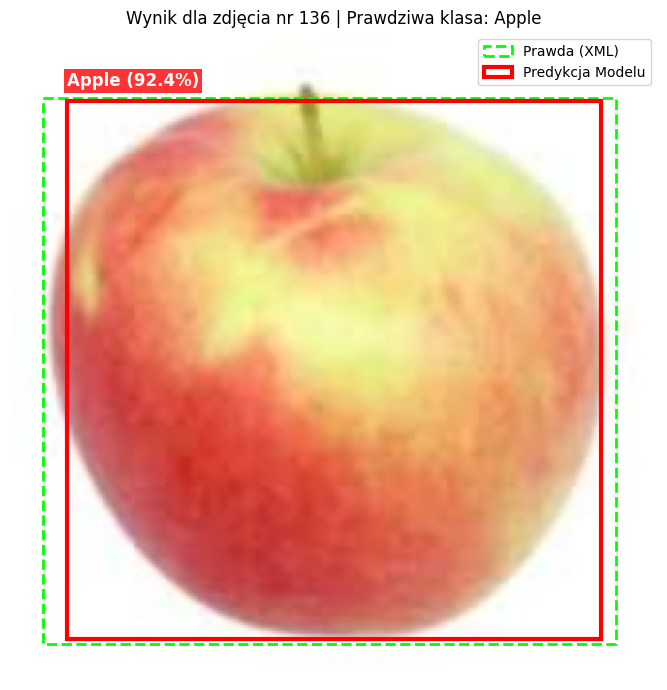

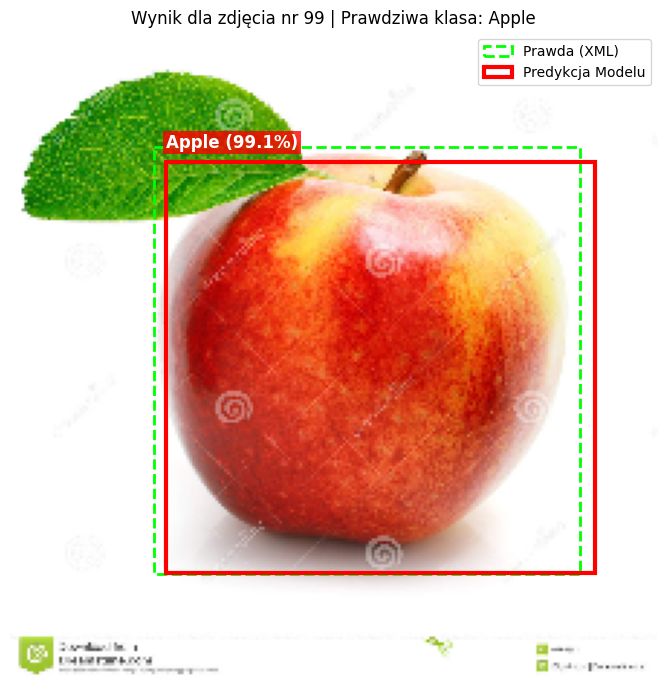

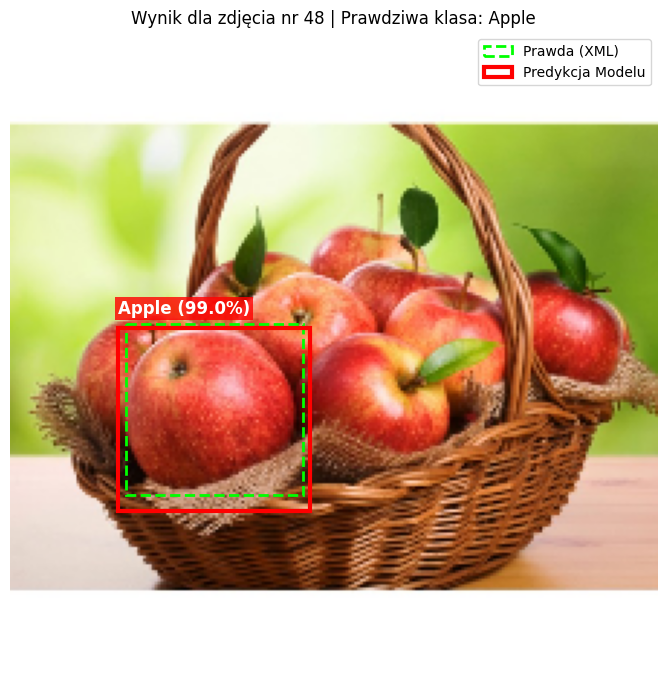

In [8]:
print("Generowanie wizualizacji...")
for _ in range(3):
    random_idx = np.random.randint(0, len(X_images) - 1)
    visualize_prediction(random_idx, model)

## Ćwiczenie 1
Przetestować model na danych testowych, ppoprawić w celu usunięcia efektu przeuczenia.

## Dataset: BCCD, Wiele obiektów na obrazie, Model: YOLO
Data: https://www.kaggle.com/datasets/orvile/bccd-blood-cell-count-and-detection-dataset/data
### Wizualizacja danych

In [ ]:
IMAGE_DIR = "./bccd/train/img/"
ANNOTATION_DIR = "./bccd/train/ann/"

sample_filename = "BloodImage_00004.jpeg"

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7F8F9C11D130>


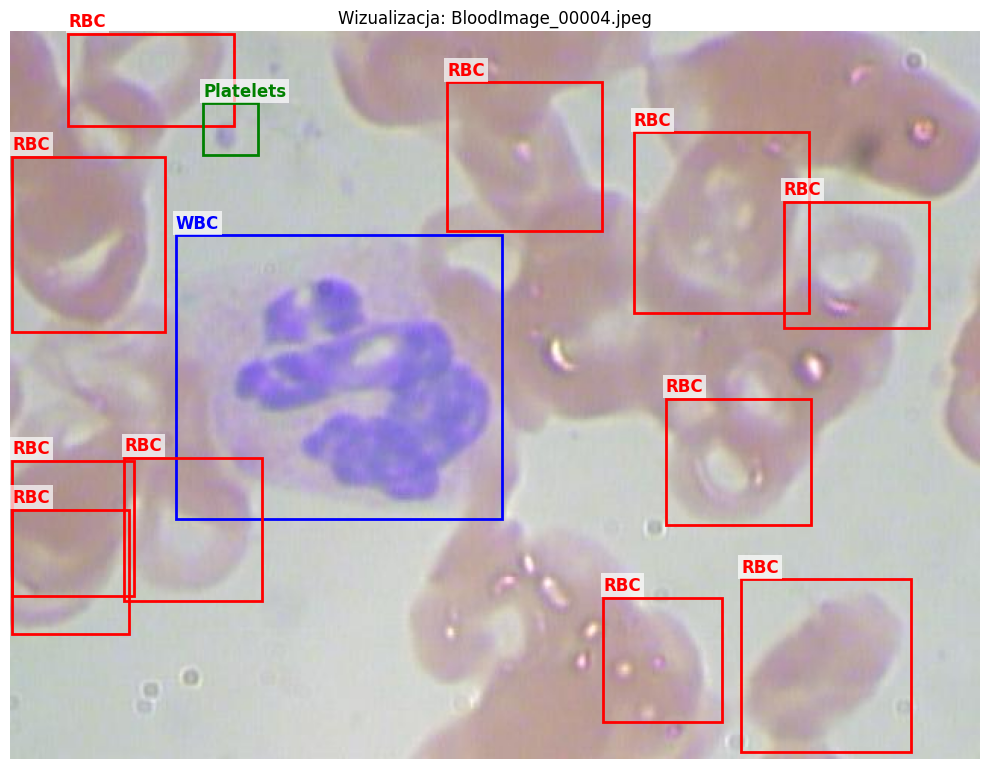

In [10]:
image = Image.open(IMAGE_DIR + sample_filename)
print(image)
fig, ax = plt.subplots(1, figsize=(10, 8))
ax.imshow(image)

with open(ANNOTATION_DIR + sample_filename + ".json", "r", encoding="utf-8") as f:
    data = json.load(f)

colors = {"RBC": "red", "WBC": "blue", "Platelets": "green"}

for obj in data.get("objects", []):
    class_name = obj["classTitle"]

    # Format bbox (xyxy): [[xmin, ymin], [xmax, ymax]]
    exterior_points = obj["points"]["exterior"]
    xmin, ymin = exterior_points[0]
    xmax, ymax = exterior_points[1]

    width = xmax - xmin
    height = ymax - ymin

    color = colors.get(class_name, "yellow")

    rect = patches.Rectangle(
        (xmin, ymin), width, height, linewidth=2, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        xmin,
        ymin - 5,
        class_name,
        color=color,
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )

plt.axis("off")  # Wyłączenie osi współrzędnych
plt.title(f"Wizualizacja: {sample_filename}")
plt.tight_layout()
plt.show()

### Przygotowanie danych dla modelu YOLO z biblioteki keras_cv

In [ ]:
CLASS_MAPPING = {"RBC": 0, "WBC": 1, "Platelets": 2}

TARGET_SHAPE = (320, 320)
BATCH_SIZE = 4

In [ ]:
def parse_annotation(image_path, json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    boxes = []
    classes = []

    for obj in data.get("objects", []):
        class_name = obj["classTitle"]

        if class_name not in CLASS_MAPPING:
            continue

        class_id = CLASS_MAPPING[class_name]

        # Oczekiwany format: [xmin, ymin, xmax, ymax] (tzw. format 'xyxy')
        exterior = obj["points"]["exterior"]
        xmin, ymin = exterior[0]
        xmax, ymax = exterior[1]

        boxes.append([xmin, ymin, xmax, ymax])
        classes.append(class_id)

    # Jeśli na obrazku nie ma obiektów, dodajemy pusty bounding box
    if len(boxes) == 0:
        boxes = tf.zeros((0, 4), dtype=tf.float32)
        classes = tf.zeros((0,), dtype=tf.float32)
    else:
        boxes = tf.cast(boxes, dtype=tf.float32)
        classes = tf.cast(classes, dtype=tf.float32)

    return image_path, boxes, classes


def data_generator():
    json_files = [f for f in os.listdir(ANNOTATION_DIR) if f.endswith(".json")]

    for json_file in json_files:
        image_filename = json_file.replace(".json", "")

        image_path = os.path.join(IMAGE_DIR, image_filename)
        json_path = os.path.join(ANNOTATION_DIR, json_file)

        if os.path.exists(image_path):
            img_path, boxes, classes = parse_annotation(image_path, json_path)
            yield img_path, boxes, classes


def load_image(image_path, boxes, classes):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    bounding_boxes = {"classes": classes, "boxes": boxes}
    return {"images": image, "bounding_boxes": bounding_boxes}

In [ ]:
dataset = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),  # Ścieżka do pliku
        tf.TensorSpec(shape=(None, 4), dtype=tf.float32),  # Bounding boxy (N, 4)
        tf.TensorSpec(shape=(None,), dtype=tf.float32),  # Klasy (N,)
    ),
)

dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
resizing_layer = keras_cv.layers.Resizing(
    TARGET_SHAPE[0],
    TARGET_SHAPE[1],
    bounding_box_format="xyxy",
    pad_to_aspect_ratio=True,
)

# ragged_batch jest kluczowy, by móc ułożyć w jednym batchu obrazy o różnej liczbie ramek
dataset = dataset.map(resizing_layer, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.ragged_batch(BATCH_SIZE, drop_remainder=True)


# Przygotowanie do trenowania
def dict_to_tuple(inputs):
    return inputs["images"], keras_cv.bounding_box.to_dense(
        inputs["bounding_boxes"], max_boxes=32
    )


dataset = dataset.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = dataset.prefetch(tf.data.AUTOTUNE)

### Tworzenie modelu YOLO

In [ ]:
backbone = keras_cv.models.YOLOV8Backbone.from_preset(
    "yolo_v8_xs_backbone_coco"
)  # Wersja "xs"

model = keras_cv.models.YOLOV8Detector(
    num_classes=3,  # Nasze 3 klasy: RBC, WBC, Platelets
    bounding_box_format="xyxy",  # Ten sam format co w naszym datasecie
    backbone=backbone,
    fpn_depth=1,  # Głębokość piramidy cech
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # Strata klasyfikacji: jak dobrze model odgaduje klasę w ramce
    classification_loss="binary_crossentropy",
    # Strata dla ramek: CIoU (Complete Intersection over Union) - ocenia jak dobrze ramka nakłada się na cel
    box_loss="ciou",
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Generuję wizualizację...


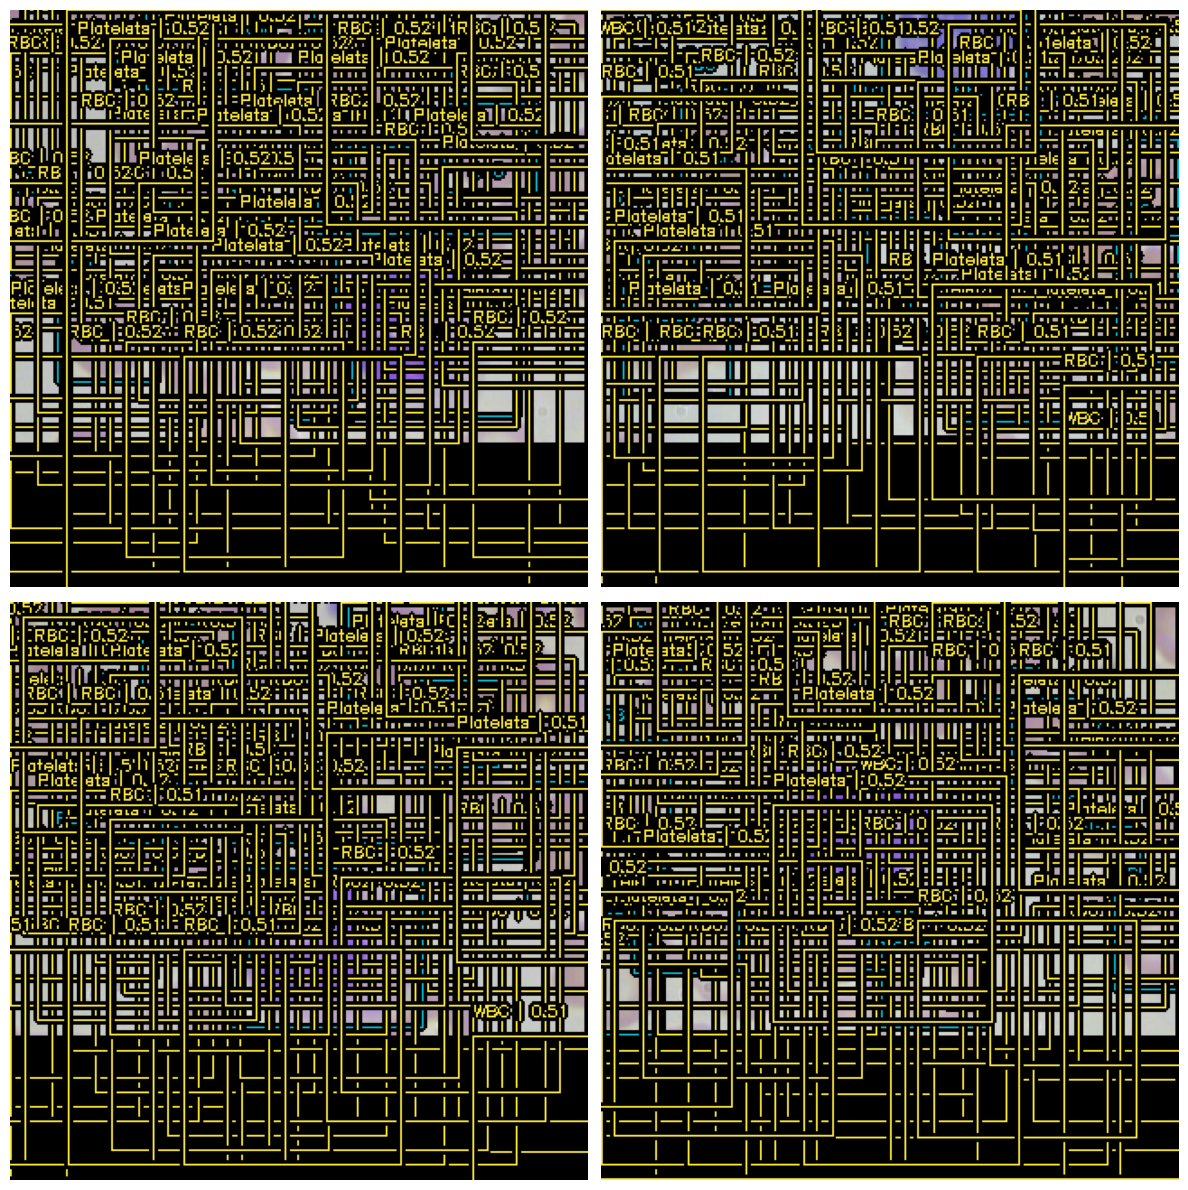

In [16]:
CLASS_MAPPING_INV = {0: "RBC", 1: "WBC", 2: "Platelets"}
images, ground_truth_boxes = next(iter(train_dataset.take(1)))
predictions = model.predict(images)
print("Generuję wizualizację...")
keras_cv.visualization.plot_bounding_box_gallery(
    images,
    value_range=(0, 255),  # Piksele w naszych obrazach są w zakresie 0-255
    bounding_box_format="xyxy",  # Format ramek, który konsekwentnie używamy
    y_true=ground_truth_boxes,  # Prawdziwe ramki (z JSON-ów)
    y_pred=predictions,  # Ramki zgadnięte przez model YOLOv8
    scale=6,  # Wielkość pojedynczego obrazka na wykresie
    rows=2,  # Liczba wierszy w siatce (zależna od BATCH_SIZE, tu: 2x2=4)
    cols=2,  # Liczba kolumn w siatce
    show=True,  # Wyświetlenie obrazka (plt.show() pod spodem)
    font_scale=0.3,  # Zmniejszona czcionka etykiet, by nie zasłaniała komórek
    class_mapping=CLASS_MAPPING_INV,  # Słownik zamieniający ID klas na ich nazwy
    line_thickness=1,  # Grubość ramek
)

In [17]:
EPOCHS = 10

history = model.fit(train_dataset, epochs=EPOCHS)

model.save_weights("yolov8_bccd_weights.weights.h5")

Epoch 1/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 85s 48ms/step - box_loss: 2.3833 - class_loss: 14.9170 - loss: 17.3002
Epoch 2/10


2026-03-23 22:38:01.213691: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2026-03-23 22:38:01.214693: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
/home/qertal/miniconda3/envs/python312/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - box_loss: 1.4846 - class_loss: 4.7443 - loss: 6.2289
Epoch 3/10


2026-03-23 22:38:04.180368: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - box_loss: 1.3263 - class_loss: 3.0956 - loss: 4.4220
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - box_loss: 1.2481 - class_loss: 2.0591 - loss: 3.3073
Epoch 5/10


2026-03-23 22:38:09.741748: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - box_loss: 1.1954 - class_loss: 1.4648 - loss: 2.6603
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - box_loss: 1.1283 - class_loss: 1.1028 - loss: 2.2311
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - box_loss: 1.1034 - class_loss: 0.8872 - loss: 1.9906
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - box_loss: 1.0916 - class_loss: 0.7318 - loss: 1.8235
Epoch 9/10


2026-03-23 22:38:21.378095: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - box_loss: 1.0259 - class_loss: 0.6094 - loss: 1.6352
Epoch 10/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - box_loss: 1.0118 - class_loss: 0.5321 - loss: 1.5440


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Generuję wizualizację...


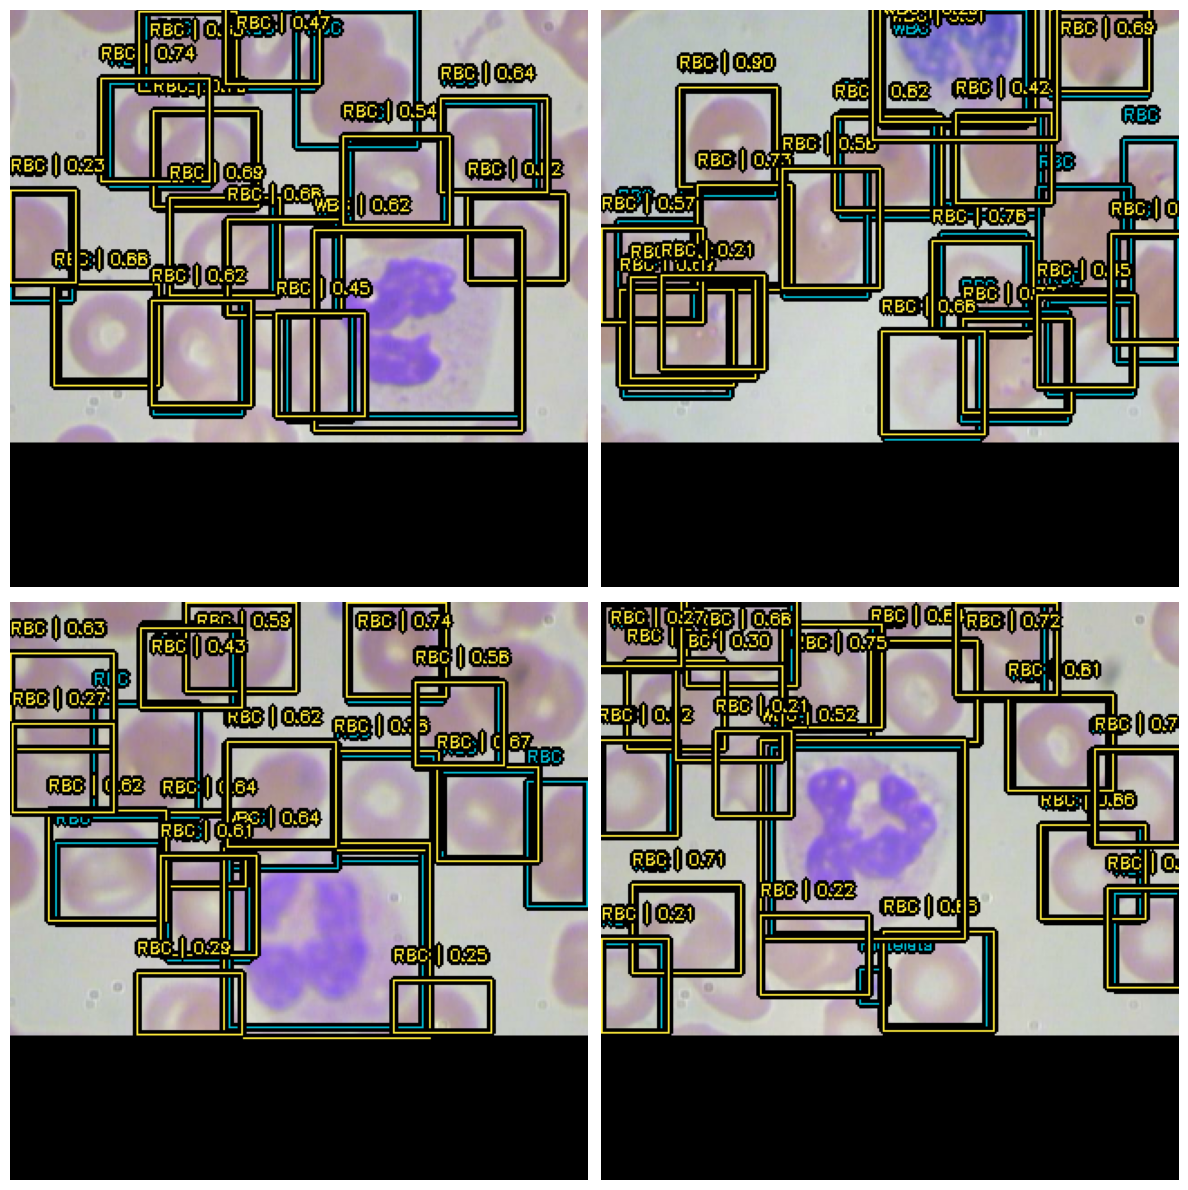

In [18]:
images, ground_truth_boxes = next(iter(train_dataset.take(1)))
predictions = model.predict(images)
print("Generuję wizualizację...")
keras_cv.visualization.plot_bounding_box_gallery(
    images,
    value_range=(0, 255),
    bounding_box_format="xyxy",
    y_true=ground_truth_boxes,
    y_pred=predictions,
    scale=6,
    rows=2,
    cols=2,
    show=True,
    font_scale=0.3,
    class_mapping=CLASS_MAPPING_INV,
    line_thickness=1,
)

## Ćwiczenie 2
Poprawić (dodać zbiór validacyjny i testowy) i dotrenować model aby osiągnąc lepsze wyniki (na zbiorze testowym).

In [19]:
SEED = 42
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
FINE_TUNE_EPOCHS = 20


def build_bccd_samples(image_dir, annotation_dir):
    samples = []

    json_files = sorted([f for f in os.listdir(annotation_dir) if f.endswith(".json")])
    for json_file in json_files:
        image_filename = json_file.replace(".json", "")
        image_path = os.path.join(image_dir, image_filename)
        json_path = os.path.join(annotation_dir, json_file)

        if os.path.exists(image_path):
            samples.append((image_path, json_path))

    return samples


def split_bccd_samples(samples, val_split=0.15, test_split=0.15, seed=42):
    samples = list(samples)
    rng = np.random.default_rng(seed)
    rng.shuffle(samples)

    total_count = len(samples)
    test_count = int(round(total_count * test_split))
    val_count = int(round(total_count * val_split))
    train_count = total_count - val_count - test_count

    train_samples = samples[:train_count]
    val_samples = samples[train_count : train_count + val_count]
    test_samples = samples[train_count + val_count :]

    return train_samples, val_samples, test_samples


samples = build_bccd_samples(IMAGE_DIR, ANNOTATION_DIR)
train_samples, val_samples, test_samples = split_bccd_samples(
    samples, val_split=VAL_SPLIT, test_split=TEST_SPLIT, seed=SEED
)

print(f"Liczba wszystkich obrazów: {len(samples)}")
print(
    f"Train: {len(train_samples)} | Validation: {len(val_samples)} | Test: {len(test_samples)}"
)

Liczba wszystkich obrazów: 205
Train: 143 | Validation: 31 | Test: 31


In [ ]:
def samples_generator(samples):
    for image_path, json_path in samples:
        yield parse_annotation(image_path, json_path)


def build_detection_dataset(samples, batch_size=BATCH_SIZE, training=False):
    dataset = tf.data.Dataset.from_generator(
        lambda: samples_generator(samples),
        output_signature=(
            tf.TensorSpec(shape=(), dtype=tf.string),
            tf.TensorSpec(shape=(None, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32),
        ),
    )

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.shuffle(
            len(samples), seed=SEED, reshuffle_each_iteration=True
        )

    dataset = dataset.map(resizing_layer, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.ragged_batch(batch_size, drop_remainder=False)
    dataset = dataset.map(dict_to_tuple, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.prefetch(tf.data.AUTOTUNE)


train_dataset_v2 = build_detection_dataset(train_samples, training=True)
val_dataset_v2 = build_detection_dataset(val_samples)
test_dataset_v2 = build_detection_dataset(test_samples)

In [21]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="yolov8_bccd_best_ex2.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
    ),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    classification_loss="binary_crossentropy",
    box_loss="ciou",
)

fine_tune_history = model.fit(
    train_dataset_v2,
    validation_data=val_dataset_v2,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - box_loss: 0.9143 - class_loss: 0.4697 - loss: 1.3841 - val_box_loss: 0.9141 - val_class_loss: 0.4500 - val_loss: 1.3578 - learning_rate: 1.0000e-04
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - box_loss: 0.8206 - class_loss: 0.4374 - loss: 1.2588 - val_box_loss: 0.9066 - val_class_loss: 0.4189 - val_loss: 1.3198 - learning_rate: 1.0000e-04
Epoch 3/20
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - box_loss: 0.7556 - class_loss: 0.4064 - loss: 1.1620

2026-03-23 22:41:18.103913: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - box_loss: 0.7581 - class_loss: 0.4025 - loss: 1.1614 - val_box_loss: 0.8992 - val_class_loss: 0.3966 - val_loss: 1.2896 - learning_rate: 1.0000e-04
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - box_loss: 0.7165 - class_loss: 0.3846 - loss: 1.1028 - val_box_loss: 0.9125 - val_class_loss: 0.3851 - val_loss: 1.2911 - learning_rate: 1.0000e-04
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - box_loss: 0.6795 - class_loss: 0.3626 - loss: 1.0415 - val_box_loss: 0.9176 - val_class_loss: 0.3753 - val_loss: 1.2861 - learning_rate: 1.0000e-04
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - box_loss: 0.6477 - class_loss: 0.3444 - loss: 0.9921 - val_box_loss: 0.9298 - val_class_loss: 0.3761 - val_loss: 1.2994 - learning_rate: 1.0000e-04
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - box_loss: 0.6214 - class_loss: 0.3244 - loss: 0.9458
Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
36/36 ━━━━━━━━━━━━━━━━━

2026-03-23 22:41:54.878877: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]


36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 193ms/step - box_loss: 0.4999 - class_loss: 0.2770 - loss: 0.7762 - val_box_loss: 0.9279 - val_class_loss: 0.3469 - val_loss: 1.2680 - learning_rate: 5.0000e-05
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - box_loss: 0.4812 - class_loss: 0.2683 - loss: 0.7499 - val_box_loss: 0.9294 - val_class_loss: 0.3437 - val_loss: 1.2664 - learning_rate: 5.0000e-05
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - box_loss: 0.4750 - class_loss: 0.2606 - loss: 0.7360 - val_box_loss: 0.9288 - val_class_loss: 0.3418 - val_loss: 1.2641 - learning_rate: 5.0000e-05
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - box_loss: 0.4623 - class_loss: 0.2532 - loss: 0.7162 - val_box_loss: 0.9390 - val_class_loss: 0.3509 - val_loss: 1.2836 - learning_rate: 5.0000e-05
Epoch 15/20
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - box_loss: 0.4767 - class_loss: 0.2492 - loss: 0.7260
Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
36/36 ━━━━━━━━━━━

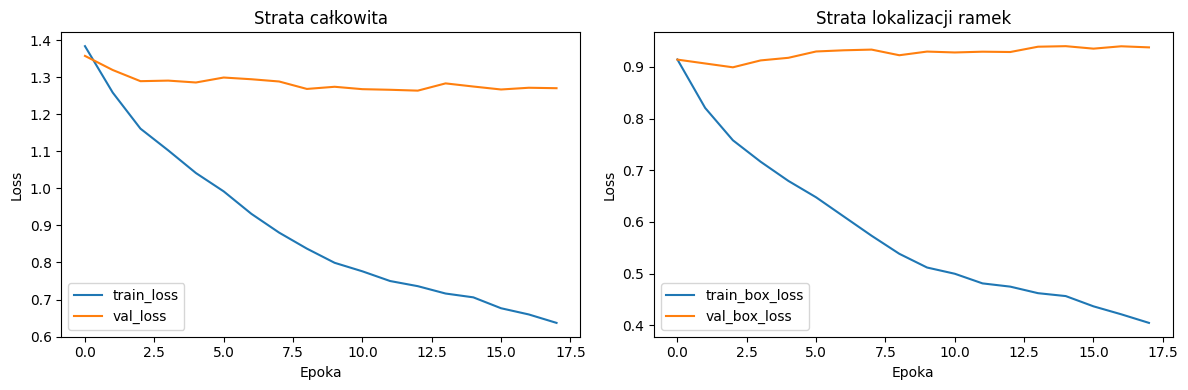

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(fine_tune_history.history["loss"], label="train_loss")
plt.plot(fine_tune_history.history["val_loss"], label="val_loss")
plt.title("Strata całkowita")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fine_tune_history.history["box_loss"], label="train_box_loss")
plt.plot(fine_tune_history.history["val_box_loss"], label="val_box_loss")
plt.title("Strata lokalizacji ramek")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
model.load_weights("yolov8_bccd_best_ex2.weights.h5")
test_results = model.evaluate(test_dataset_v2, return_dict=True)

print("Wyniki na zbiorze testowym:")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - box_loss: 0.8876 - class_loss: 0.3454 - loss: 1.2338
Wyniki na zbiorze testowym:
box_loss: 0.8876
class_loss: 0.3454
loss: 1.2338


1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Generuję wizualizację predykcji na zbiorze testowym...


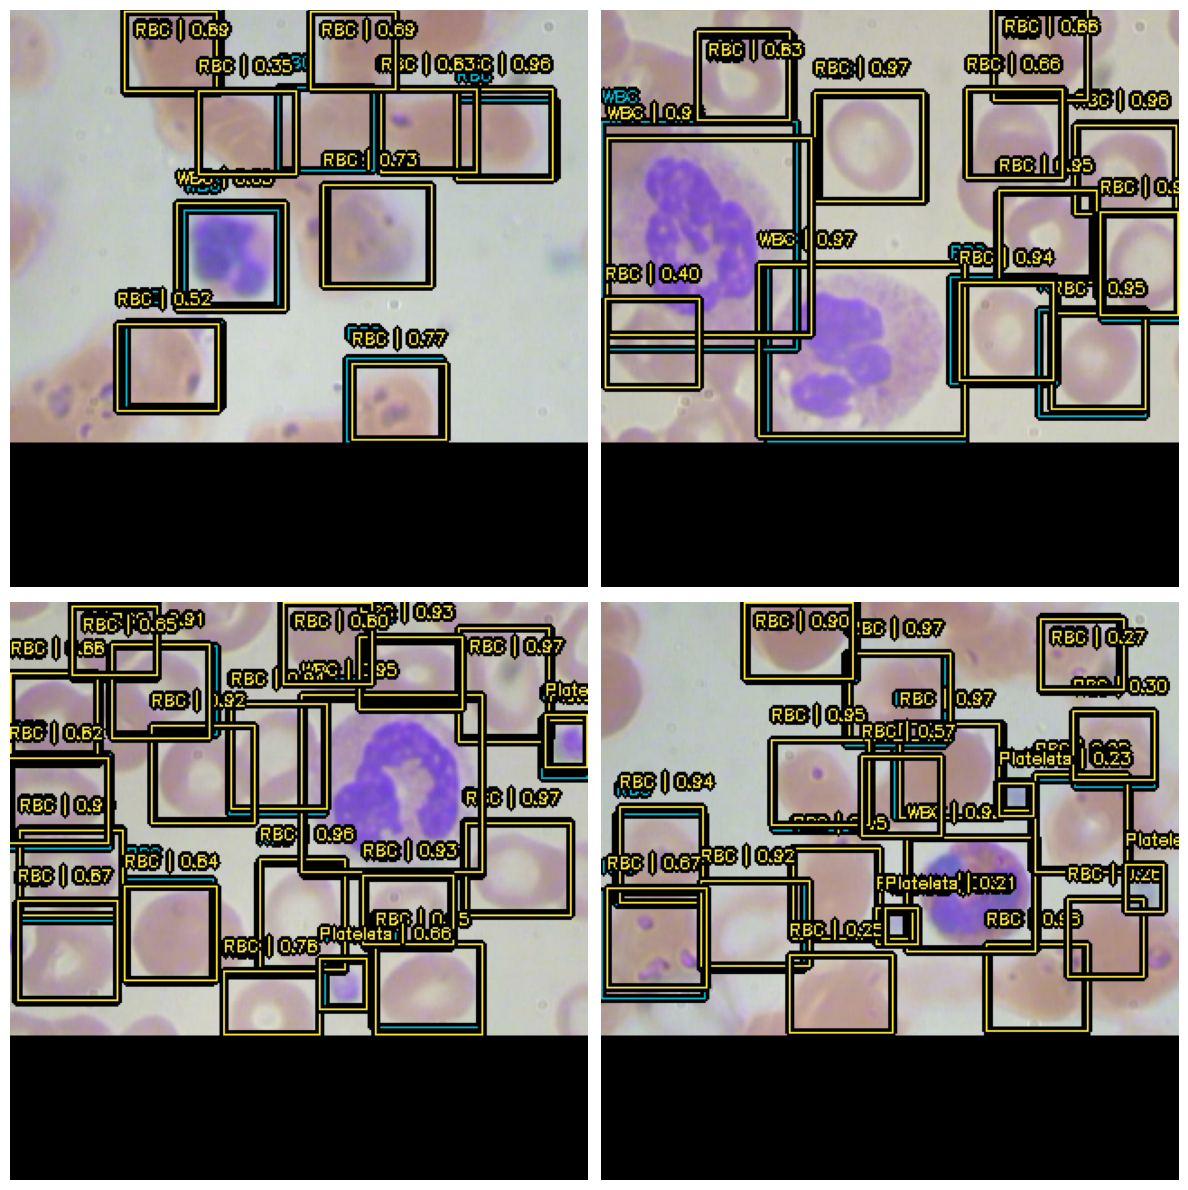

: 

In [ ]:
images, ground_truth_boxes = next(iter(test_dataset_v2.take(1)))
predictions = model.predict(images)

print("Generuję wizualizację predykcji na zbiorze testowym...")
keras_cv.visualization.plot_bounding_box_gallery(
    images,
    value_range=(0, 255),
    bounding_box_format="xyxy",
    y_true=ground_truth_boxes,
    y_pred=predictions,
    scale=6,
    rows=2,
    cols=2,
    show=True,
    font_scale=0.3,
    class_mapping=CLASS_MAPPING_INV,
    line_thickness=1,
)